<a href="https://colab.research.google.com/github/nahmxp/rl-for-data-scientists/blob/main/notebooks/chapter_03_mdps/03_markov_chains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Markov Decision Processes (MDPs) for Clickstream Analysis

This notebook demonstrates how to model user behavior as an MDP and analyze the impact of the discount factor $\gamma$ on state values.

### Learning Objectives
1.  Define states, actions, transitions, and rewards.
2.  Understand the Bellman Equation for policy evaluation.
3.  Visualize how the planning horizon changes with $\gamma$.

# Chapter 3 — Markov Chains & MDPs## Concept Notebooks[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)**No GPU required. Runtime: ~20 minutes.**This notebook implements:- Markov chains and stationary distributions- A full MDP with state transitions, actions, and rewards- Value computation via Bellman equation iteration- Visualisation of discount factor γ effects

In [1]:
import numpy as np
import matplotlib.pyplot as plt
print('Ready')

Ready


### 1. Defining the Environment
We model a user's journey through five states: `Homepage`, `Product`, `Cart`, `Purchase`, and `Exit`. The system can choose between two actions:
*   **Action 0**: Recommend nothing.
*   **Action 1**: Recommend aggressively.

Rewards are assigned to encourage purchases (+10) and discourage exits (-1).

## 3.1 Defining an MDP: The Clickstream ExampleFrom Chapter 3: a user navigating a website is an MDP.- **States**: page types (Homepage, Product, Cart, Purchase, Exit)- **Actions**: (from system perspective) which products to recommend- **Rewards**: +10 at Purchase, -1 at Exit, 0 elsewhere- **Transitions**: probabilistic (user clicks follow a distribution)

In [2]:
# Clickstream MDP
states = ['Homepage', 'Product', 'Cart', 'Purchase', 'Exit']
S = len(states)
state_idx = {s: i for i, s in enumerate(states)}

# Transition probabilities P[s][a][s']
# Action 0 = recommend nothing, Action 1 = recommend aggressively
P = np.zeros((S, 2, S))  # P[state, action, next_state]
# ... (simplified transitions)
P[0, 0] = [0.3, 0.4, 0.1, 0.0, 0.2]  # Homepage, no rec
P[0, 1] = [0.1, 0.6, 0.2, 0.0, 0.1]  # Homepage, rec
P[1, 0] = [0.2, 0.2, 0.3, 0.0, 0.3]  # Product, no rec
P[1, 1] = [0.1, 0.2, 0.5, 0.0, 0.2]  # Product, rec
P[2, 0] = [0.0, 0.1, 0.2, 0.4, 0.3]  # Cart, no rec
P[2, 1] = [0.0, 0.0, 0.1, 0.7, 0.2]  # Cart, rec
P[3, :] = [0.0, 0.0, 0.0, 1.0, 0.0]  # Purchase (absorbing)
P[4, :] = [0.0, 0.0, 0.0, 0.0, 1.0]  # Exit (absorbing)

R = np.array([0, 0, 0, 10, -1])  # rewards per state
print('MDP defined. States:', states)
print('Rewards:', dict(zip(states, R)))

MDP defined. States: ['Homepage', 'Product', 'Cart', 'Purchase', 'Exit']
Rewards: {'Homepage': np.int64(0), 'Product': np.int64(0), 'Cart': np.int64(0), 'Purchase': np.int64(10), 'Exit': np.int64(-1)}


### 2. Policy Evaluation and the Bellman Equation
To find the value of each state $V(s)$ under a specific policy, we use the iterative policy evaluation method based on the Bellman equation:
$$V(s) = R(s) + \gamma \sum_{s'} P(s' | s, a) V(s')$$

Where:
*   $R(s)$ is the immediate reward.
*   $\gamma$ (Gamma) is the discount factor.
*   $P$ is the transition probability.

## 3.2 The Effect of Discount Factor γγ controls how much the agent values future rewards. Low γ → shortsighted. High γ → far-sighted.

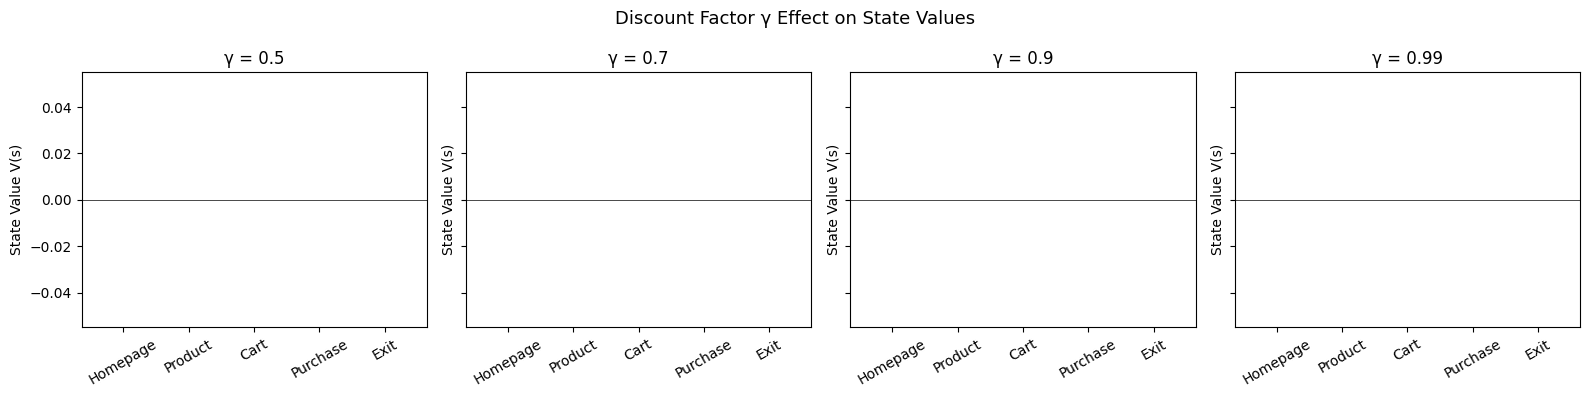

In [3]:
def compute_value_iteration(P, R, gamma, policy, n_iter=100):
    """Simple policy evaluation for a fixed policy."""
    S = len(R)
    V = np.zeros(S)
    for _ in range(n_iter):
        V_new = np.copy(V)
        for s in range(S-2):  # skip absorbing states
            V_new[s] = R[s] + gamma * np.dot(P[s, policy[s]], V)
        V = V_new
    return V

# Aggressive policy (always recommend)
agressive_policy = np.ones(5, dtype=int)

gammas = [0.5, 0.7, 0.9, 0.99]
fig, axes = plt.subplots(1, len(gammas), figsize=(16, 4), sharey=True)
for ax, gamma in zip(axes, gammas):
    V = compute_value_iteration(P, R, gamma, agressive_policy)
    colors = ['steelblue' if v >= 0 else 'tomato' for v in V]
    ax.bar(states, V, color=colors)
    ax.set_title(f'γ = {gamma}')
    ax.set_ylabel('State Value V(s)')
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(0, color='black', linewidth=0.5)
plt.suptitle('Discount Factor γ Effect on State Values', fontsize=13)
plt.tight_layout()
plt.show()

### 3. Analysis
Observe how as $\gamma$ increases towards 1, the value of early states like `Homepage` and `Product` increases because the agent places more weight on the potential future +10 reward at the `Purchase` state.

## ✅ Key Takeaways1. An MDP is defined by (S, A, P, R, γ): states, actions, transitions, rewards, discount2. The discount factor γ controls the planning horizon3. Value functions encode the expected cumulative reward from each state4. Stationary distributions describe long-run behaviour of Markov chains